In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
# load the dataset
social = pd.read_csv('Students Social Media Addiction.csv')
# select relevant columns
filtered_data = social[['Age',
                        'Avg_Daily_Usage_Hours',
                        'Sleep_Hours_Per_Night',
                        'Mental_Health_Score',
                        'Conflicts_Over_Social_Media',
                        'Gender',
                        'Academic_Level',
                        'Most_Used_Platform',
                        'Relationship_Status',
                        'Addicted_Score']].copy()
# handle missing data
num_cols = ['Age',
            'Avg_Daily_Usage_Hours',
            'Sleep_Hours_Per_Night',
            'Mental_Health_Score',
            'Conflicts_Over_Social_Media',
            'Addicted_Score']
for col in num_cols:
    filtered_data[col] = filtered_data[col].fillna(filtered_data[col].mean())

filtered_data['Gender'] = filtered_data['Gender'].fillna(filtered_data['Gender'].mode()[0])
filtered_data['Academic_Level'] = filtered_data['Academic_Level'].fillna(filtered_data['Academic_Level'].mode()[0])
filtered_data['Most_Used_Platform'] = filtered_data['Most_Used_Platform'].fillna(filtered_data['Most_Used_Platform'].mode()[0])
filtered_data['Relationship_Status'] = filtered_data['Relationship_Status'].fillna(filtered_data['Relationship_Status'].mode()[0])
# creating target variable
filtered_data['addiction_category'] = np.where(filtered_data['Addicted_Score'] >= 5, 1, 0)
# encode ordinal variable
academic_order = {
    'High School': 0,
    'Undergraduate': 1,
    'Graduate': 2
}
filtered_data['Academic_Level'] = filtered_data['Academic_Level'].map(academic_order)
# one-hot encoding
filtered_data = pd.get_dummies(filtered_data, columns=['Gender',
                                                       'Most_Used_Platform',
                                                       'Relationship_Status'])
filtered_data = filtered_data.astype(float)  # convert True/False to 1/0

# Detecting and removing outliers

In [6]:
# detecting outliers
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] < lower) | (data[column] > upper)]
outliers_list = []
for col in ['Age',
            'Avg_Daily_Usage_Hours',
            'Sleep_Hours_Per_Night',
            'Mental_Health_Score',
            'Conflicts_Over_Social_Media']:
    outliers_list.append(detect_outliers(filtered_data, col))
outliers = pd.concat(outliers_list).drop_duplicates()
no_outlier_data = filtered_data[~filtered_data.index.isin(outliers.index)]

# Splitting the Data

In [7]:
# independent variables (X)
X = no_outlier_data.drop(columns=['Addicted_Score', 'addiction_category'])
# target variable (y)
y = no_outlier_data['Addicted_Score']
# split the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression (Degree 2)": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Elastic Net Regression": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

poly_features = PolynomialFeatures(degree=2)
X_poly_train = poly_features.fit_transform(X_train)
X_poly_test = poly_features.transform(X_test)

results = []
predicted_values = {}

for name, model in models.items():
    if "Polynomial" in name:
        model.fit(X_poly_train, y_train)
        y_pred = model.predict(X_poly_test)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "Mean Squared Error": mse, "R-squared": r2})
    predicted_values[name] = y_pred

comparison_results = pd.DataFrame(results)

# Identify the best-fit model based on R-squared
best_model_name = comparison_results.loc[comparison_results['R-squared'].idxmax(), 'Model']
best_model_r2 = comparison_results.loc[comparison_results['R-squared'].idxmax(), 'R-squared']
best_model_mse = comparison_results.loc[comparison_results['R-squared'].idxmax(), 'Mean Squared Error']

print("Comparison of Regression Models:")
print(comparison_results)
print(f"\nBest-Fit Model: {best_model_name}")
print(f"R-squared: {best_model_r2}")
print(f"Mean Squared Error: {best_model_mse}")

Comparison of Regression Models:
                              Model  Mean Squared Error  R-squared
0                 Linear Regression            0.105982   0.946411
1  Polynomial Regression (Degree 2)            0.443509   0.775741
2                  Ridge Regression            0.105755   0.946526
3                  Lasso Regression            0.142586   0.927902
4            Elastic Net Regression            0.144676   0.926845

Best-Fit Model: Ridge Regression
R-squared: 0.9465256213395385
Mean Squared Error: 0.10575452040501095


In [9]:
# Print Regression Equation for the Best-Fit Model
if best_model_name == "Polynomial Regression (Degree 2)":
    coefficients = poly_model.coef_
    intercept = poly_model.intercept_
    feature_names = poly_features.get_feature_names_out(X.columns)
    print("\nPolynomial Regression Equation (Degree 2):")
    equation = f"y = {intercept:.2f} "
    for coef, feature in zip(coefficients, feature_names):
        equation += f"+ ({coef:.2f})*{feature} "
    print(equation)
else:
    best_model = models[best_model_name]
    intercept = best_model.intercept_
    coefficients = best_model.coef_
    print(f"\nRegression Equation for {best_model_name}:")
    equation = f"y = {intercept:.2f} "
    for coef, feature in zip(coefficients, X.columns):
        equation += f"+ ({coef:.2f})*{feature} "
    print(equation)


Regression Equation for Ridge Regression:
y = 10.78 + (-0.07)*Age + (0.09)*Avg_Daily_Usage_Hours + (-0.19)*Sleep_Hours_Per_Night + (-0.65)*Mental_Health_Score + (0.57)*Conflicts_Over_Social_Media + (0.26)*Academic_Level + (0.00)*Gender_Female + (-0.00)*Gender_Male + (-0.01)*Most_Used_Platform_Facebook + (0.12)*Most_Used_Platform_Instagram + (-0.39)*Most_Used_Platform_KakaoTalk + (-0.64)*Most_Used_Platform_LINE + (0.04)*Most_Used_Platform_LinkedIn + (0.32)*Most_Used_Platform_Snapchat + (0.33)*Most_Used_Platform_TikTok + (-0.10)*Most_Used_Platform_Twitter + (-0.16)*Most_Used_Platform_VKontakte + (0.07)*Most_Used_Platform_WeChat + (-0.03)*Most_Used_Platform_WhatsApp + (0.46)*Most_Used_Platform_YouTube + (0.07)*Relationship_Status_Complicated + (-0.03)*Relationship_Status_In Relationship + (-0.04)*Relationship_Status_Single 


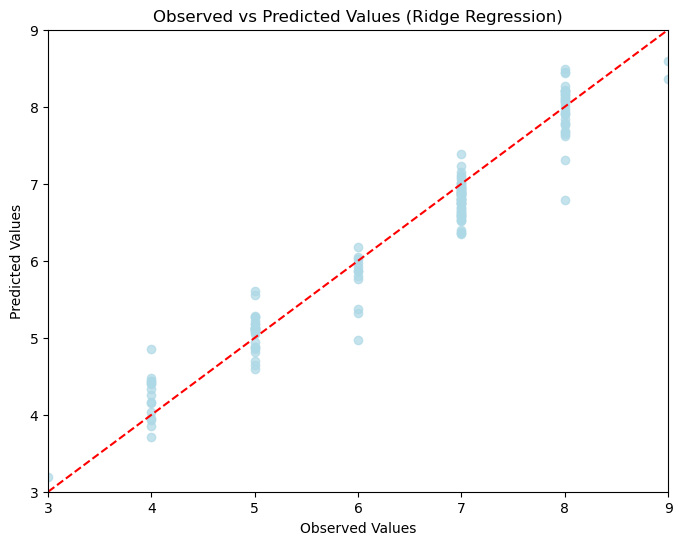

In [10]:
# Plot Observed vs. Predicted values for the best model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predicted_values[best_model_name], alpha=0.7, color='lightblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())

plt.title(f"Observed vs Predicted Values ({best_model_name})")
plt.xlabel("Observed Values")
plt.ylabel("Predicted Values")
plt.show()

In [11]:
filtered_data['addiction_category'] = np.where(filtered_data['Addicted_Score'] >= 5, 1, 0)
print(filtered_data['addiction_category'].value_counts())

addiction_category
1    605
0    100
Name: count, dtype: int64


In [12]:
# re-define X & y for classification reasons
X = no_outlier_data.drop(columns=['Addicted_Score', 'addiction_category'])
y = no_outlier_data['addiction_category'].astype(int)
print(y.unique())

# split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

[1 0]


In [13]:
# import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()
    errors = FP + FN
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "Confusion Matrix": cm,
        "Errors (FP + FN)": errors
    })
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-score  \
0  Logistic Regression  0.992908   0.992000  1.000000  0.995984   
1                  KNN  0.985816   0.991935  0.991935  0.991935   
2          Naive Bayes  0.780142   1.000000  0.750000  0.857143   
3        Decision Tree  0.985816   0.991935  0.991935  0.991935   
4        Random Forest  0.992908   0.992000  1.000000  0.995984   
5                  SVM  0.900709   0.898551  1.000000  0.946565   

      Confusion Matrix  Errors (FP + FN)  
0  [[16, 1], [0, 124]]                 1  
1  [[16, 1], [1, 123]]                 2  
2  [[17, 0], [31, 93]]                31  
3  [[16, 1], [1, 123]]                 2  
4  [[16, 1], [0, 124]]                 1  
5  [[3, 14], [0, 124]]                14  


In [20]:
results_df = pd.DataFrame(results)

# round accuracy to make it clean
results_df = results_df[['Model', 'Confusion Matrix', 'Errors (FP + FN)', 'Accuracy']]
# display as table (Jupyter)
results_df

,Model,Confusion Matrix,Errors (FP + FN),Accuracy
0,Logistic Regression,"[[16, 1], [0, 124]]",1,0.992908
1,KNN,"[[16, 1], [1, 123]]",2,0.985816
2,Naive Bayes,"[[17, 0], [31, 93]]",31,0.780142
3,Decision Tree,"[[16, 1], [1, 123]]",2,0.985816
4,Random Forest,"[[16, 1], [0, 124]]",1,0.992908
5,SVM,"[[3, 14], [0, 124]]",14,0.900709


In [14]:
best_model = models["Logistic Regression"]   # or Random Forest 
y_pred_best = best_model.predict(X_test)

pred_count = pd.Series(y_pred_best).value_counts()
print(pred_count)

1    125
0     16
Name: count, dtype: int64


In [16]:
import warnings
warnings.filterwarnings('ignore')

# K-means Clustering

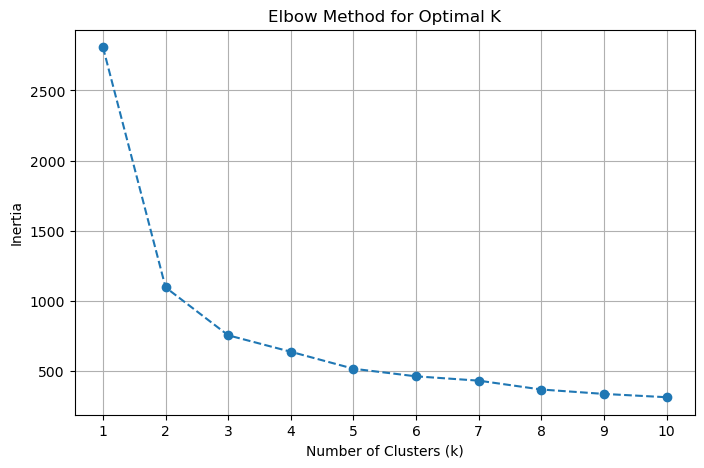

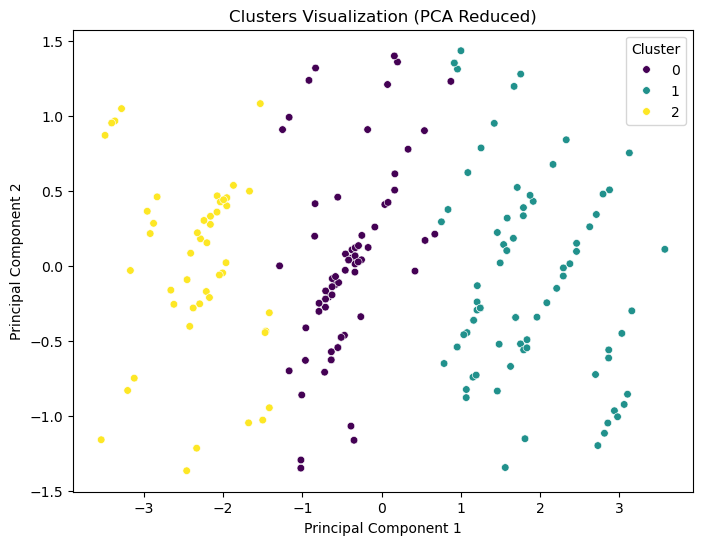

Cluster Centers (Scaled Data):
[[ 0.08739916 -0.13701343 -0.33531739  0.20121196]
 [-0.8781282   0.8649215   1.02602779 -0.98815261]
 [ 1.2179857  -1.1335157  -1.12022227  1.23698325]]

Cluster Statistics:
         Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  Mental_Health_Score  \
Cluster                                                                      
0                     5.021757               6.723013             5.857741   
1                     3.826165               7.841219             7.354839   
2                     6.421739               5.610870             4.994565   

         Conflicts_Over_Social_Media      PCA1      PCA2  
Cluster                                                   
0                           3.041841 -0.382515  0.111099  
1                           1.910394  1.880479 -0.074717  
2                           4.027174 -2.354525 -0.031015  


In [17]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
# select relevant columns
data = no_outlier_data[['Avg_Daily_Usage_Hours',
                        'Sleep_Hours_Per_Night',
                        'Mental_Health_Score',
                        'Conflicts_Over_Social_Media']].copy()
# handle missing values
data = data.fillna(data.mean())
# scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
# elbow method
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)
# plot elbow
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.grid(True)
plt.show()
# apply k-means (k=3)
k = 3
kmeans = KMeans(n_clusters=k, random_state=1)
clusters = kmeans.fit_predict(data_scaled)
data['Cluster'] = clusters
# PCA visualization
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)
data['PCA1'] = data_pca[:, 0]
data['PCA2'] = data_pca[:, 1]
sample_data = data.sample(n=200, random_state=42)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=sample_data, palette='viridis', s=30)
plt.title("Clusters Visualization (PCA Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Cluster')
plt.show()
# cluster centers
print("Cluster Centers (Scaled Data):")
print(kmeans.cluster_centers_)
# cluster statistics
print("\nCluster Statistics:")
print(data.groupby('Cluster').mean())

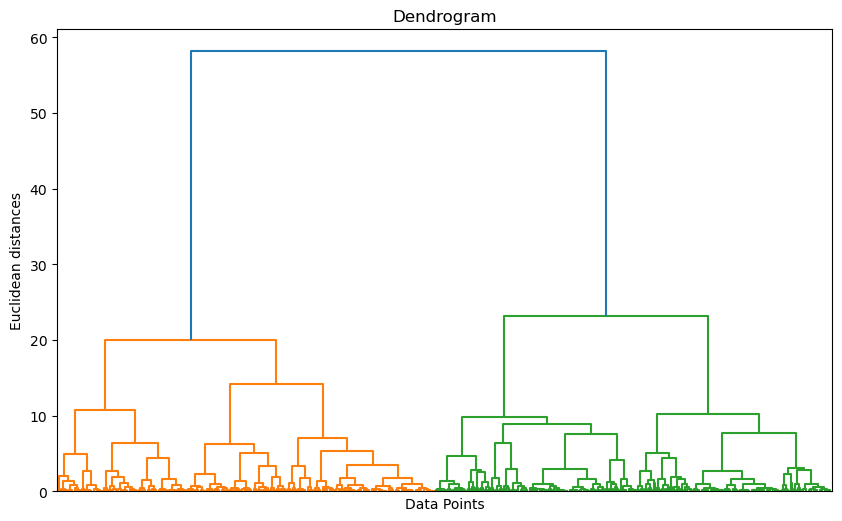

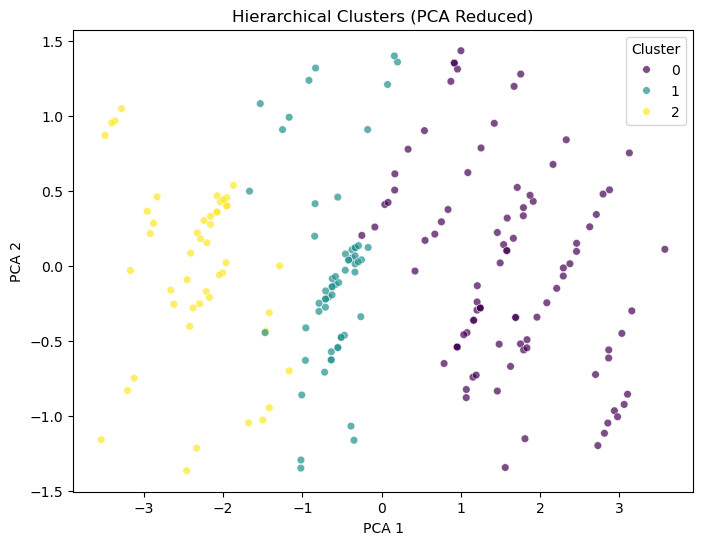

Hierarchical Cluster Statistics:
            Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  Mental_Health_Score  \
HC_Cluster                                                                      
0                        3.961516               7.775802             7.131195   
1                        5.184746               6.448588             5.717514   
2                        6.443956               5.595604             5.016484   

            Conflicts_Over_Social_Media   Cluster      PCA1      PCA2  
HC_Cluster                                                             
0                              2.113703  0.813411  1.584965  0.045758  
1                              3.079096  0.067797 -0.650688 -0.029159  
2                              4.016484  1.956044 -2.354237 -0.057878  


In [18]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns
# Dendrogram
plt.figure(figsize=(10, 6))
sch.dendrogram(sch.linkage(data_scaled, method='ward'), no_labels=True)
plt.title('Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Euclidean distances')
plt.show()
# Apply Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(data_scaled)
# Add Cluster Labels
data['HC_Cluster'] = y_hc
# Plot
sample_data_hc = data.sample(n=200, random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='HC_Cluster',
    data=sample_data_hc,
    palette='viridis',
    s=30,
    alpha=0.7
)
plt.title('Hierarchical Clusters (PCA Reduced)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()
# Cluster statistics
print("Hierarchical Cluster Statistics:")
print(data.groupby('HC_Cluster').mean())

In [ ]:
# test 2